In [1]:
# Set Up Google Colab & Mount Drive

from google.colab import drive
drive.mount('/content/drive')

# Install required libraries
!pip install rembg torch torchvision timm pillow matplotlib scikit-learn

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

DATASET_PATH = "/content/drive/MyDrive/rice_disease_dataset"

for cls in os.listdir(DATASET_PATH):
    count = len(os.listdir(os.path.join(DATASET_PATH, cls)))
    print(f"{cls}: {count} images")

brown_spot: 40 images
leaf_smut: 40 images
bacterial_leaf_blight: 40 images


In [3]:
# Data Augmentation (Critical because we Only Have 40 Images Per Class!)

import torchvision.transforms as transforms

# Training transforms — heavy augmentation
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Validation/test transforms — no augmentation
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [4]:
# Build the Dataset Loader

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

full_dataset = ImageFolder(root=DATASET_PATH, transform=train_transforms)

# 70% train, 15% val, 15% test
total = len(full_dataset)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])

# Apply val transforms to val/test sets
val_set.dataset.transform = val_transforms
test_set.dataset.transform = val_transforms

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=16, shuffle=False)

CLASS_NAMES = full_dataset.classes
print("Classes:", CLASS_NAMES)

Classes: ['bacterial_leaf_blight', 'brown_spot', 'leaf_smut']


In [5]:
# Build the Model (Transfer Learning with EfficientNet)

import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(pretrained=True)

# Freeze all base layers
for param in model.parameters():
    param.requires_grad = False

# Replace the classifier head for 3 classes
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.classifier[1].in_features, 3)
)

model = model.to(device)

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s]


In [6]:
# Train the Model

from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.classifier.parameters(), lr=1e-3)
scheduler = StepLR(optimizer, step_size=5, gamma=0.5)

def train_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

# Training loop
EPOCHS = 20
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc     = eval_epoch(model, val_loader)
    scheduler.step()
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.2%} | Val Acc: {val_acc:.2%}")

# Save the model
torch.save(model.state_dict(), "/content/drive/MyDrive/rice_disease_model.pth")
print("Model saved!")

Epoch 1/20 | Train Acc: 34.52% | Val Acc: 83.33%
Epoch 2/20 | Train Acc: 69.05% | Val Acc: 83.33%
Epoch 3/20 | Train Acc: 83.33% | Val Acc: 88.89%
Epoch 4/20 | Train Acc: 88.10% | Val Acc: 83.33%
Epoch 5/20 | Train Acc: 90.48% | Val Acc: 83.33%
Epoch 6/20 | Train Acc: 91.67% | Val Acc: 83.33%
Epoch 7/20 | Train Acc: 90.48% | Val Acc: 83.33%
Epoch 8/20 | Train Acc: 88.10% | Val Acc: 83.33%
Epoch 9/20 | Train Acc: 86.90% | Val Acc: 83.33%
Epoch 10/20 | Train Acc: 89.29% | Val Acc: 83.33%
Epoch 11/20 | Train Acc: 90.48% | Val Acc: 83.33%
Epoch 12/20 | Train Acc: 89.29% | Val Acc: 77.78%
Epoch 13/20 | Train Acc: 88.10% | Val Acc: 83.33%
Epoch 14/20 | Train Acc: 94.05% | Val Acc: 83.33%
Epoch 15/20 | Train Acc: 89.29% | Val Acc: 77.78%
Epoch 16/20 | Train Acc: 90.48% | Val Acc: 77.78%
Epoch 17/20 | Train Acc: 94.05% | Val Acc: 77.78%
Epoch 18/20 | Train Acc: 91.67% | Val Acc: 77.78%
Epoch 19/20 | Train Acc: 91.67% | Val Acc: 77.78%
Epoch 20/20 | Train Acc: 92.86% | Val Acc: 77.78%
Model sav

                       precision    recall  f1-score   support

bacterial_leaf_blight       0.70      1.00      0.82         7
           brown_spot       1.00      0.40      0.57         5
            leaf_smut       0.83      0.83      0.83         6

             accuracy                           0.78        18
            macro avg       0.84      0.74      0.74        18
         weighted avg       0.83      0.78      0.76        18



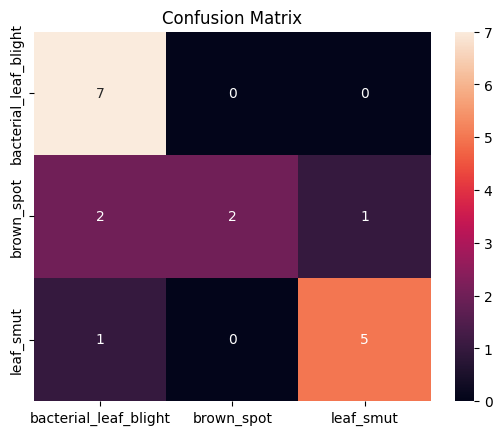

In [23]:
# Evaluate on Test Set

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = outputs.argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.show()

In [8]:
# Background Removing Library

!pip install "rembg[gpu]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 1.7 MB/s eta 0:00:00


In [9]:
# Preprocessing Pipeline for Farmer-Uploaded Images

from rembg import remove
from PIL import Image, ImageOps
import numpy as np
import io

def preprocess_farmer_image(image_path):
    """
    Full preprocessing pipeline:
    1. Remove background
    2. Crop tightly around the leaf
    3. Resize to model input size
    """
    # Step 1: Load image
    img = Image.open(image_path).convert("RGBA")

    # Step 2: Remove background using rembg
    img_bytes = io.BytesIO()
    img.save(img_bytes, format="PNG")
    img_no_bg = remove(img_bytes.getvalue())  # Returns bytes
    img_no_bg = Image.open(io.BytesIO(img_no_bg)).convert("RGBA")

    # Step 3: Crop tightly — find bounding box of non-transparent pixels
    bbox = img_no_bg.getbbox()
    if bbox:
        img_cropped = img_no_bg.crop(bbox)
    else:
        img_cropped = img_no_bg

    # Step 4: Convert to RGB and resize
    img_rgb = img_cropped.convert("RGB")
    img_final = img_rgb.resize((224, 224))

    return img_final


def predict_disease(image_path, model, class_names):
    """Run full pipeline: preprocess → predict → return result"""
    import torch.nn.functional as F

    # Preprocess
    img = preprocess_farmer_image(image_path)

    # Apply val transforms
    img_tensor = val_transforms(img).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs = F.softmax(output, dim=1)[0]
        pred_idx = probs.argmax().item()

    predicted_class = class_names[pred_idx]
    confidence = probs[pred_idx].item()

    return {
        "disease": predicted_class,
        "confidence": f"{confidence:.1%}",
        "all_probs": {class_names[i]: f"{probs[i].item():.1%}" for i in range(len(class_names))}
    }

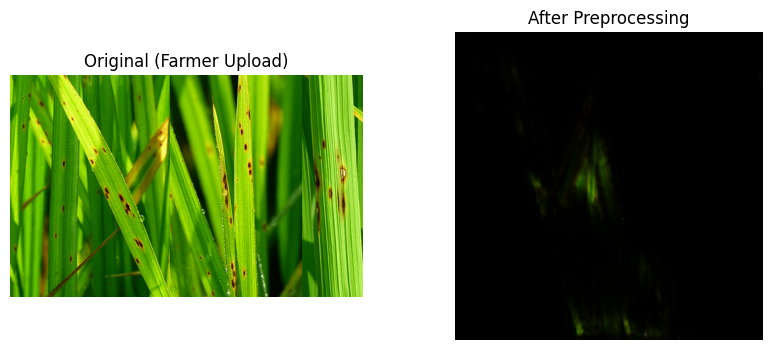


Predicted Disease : Brown Spot
Confidence        : 46.3%

All Probabilities:
  bacterial_leaf_blight: 24.9%
  brown_spot: 46.3%
  leaf_smut: 28.8%


In [17]:
# Real World Images Testing
import matplotlib.pyplot as plt

def show_prediction(image_path):
    # Preprocess and show intermediate result
    processed = preprocess_farmer_image(image_path)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(Image.open(image_path))
    axes[0].set_title("Original (Farmer Upload)")
    axes[0].axis("off")

    axes[1].imshow(processed)
    axes[1].set_title("After Preprocessing")
    axes[1].axis("off")
    plt.show()

    # Predict
    result = predict_disease(image_path, model, CLASS_NAMES)
    print(f"\nPredicted Disease : {result['disease'].replace('_', ' ').title()}")
    print(f"Confidence        : {result['confidence']}")
    print(f"\nAll Probabilities:")
    for disease, prob in result['all_probs'].items():
        print(f"  {disease}: {prob}")

# Test it
show_prediction("brown spot test 2.png")

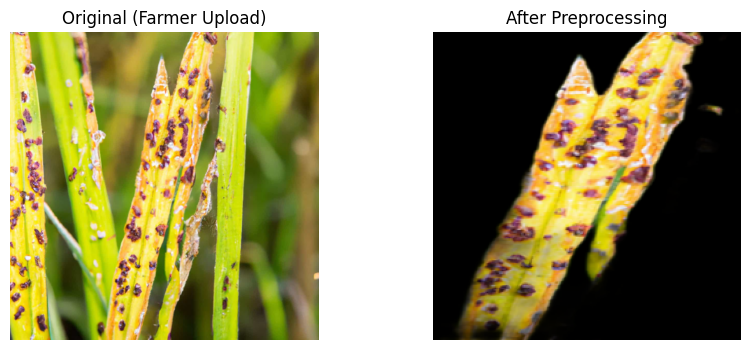


Predicted Disease : Brown Spot
Confidence        : 39.0%

All Probabilities:
  bacterial_leaf_blight: 24.4%
  brown_spot: 39.0%
  leaf_smut: 36.7%


In [20]:
# Real World Images Testing
import matplotlib.pyplot as plt

def show_prediction(image_path):
    # Preprocess and show intermediate result
    processed = preprocess_farmer_image(image_path)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(Image.open(image_path))
    axes[0].set_title("Original (Farmer Upload)")
    axes[0].axis("off")

    axes[1].imshow(processed)
    axes[1].set_title("After Preprocessing")
    axes[1].axis("off")
    plt.show()

    # Predict
    result = predict_disease(image_path, model, CLASS_NAMES)
    print(f"\nPredicted Disease : {result['disease'].replace('_', ' ').title()}")
    print(f"Confidence        : {result['confidence']}")
    print(f"\nAll Probabilities:")
    for disease, prob in result['all_probs'].items():
        print(f"  {disease}: {prob}")

# Test it
show_prediction("bown spot test 3.jpg")

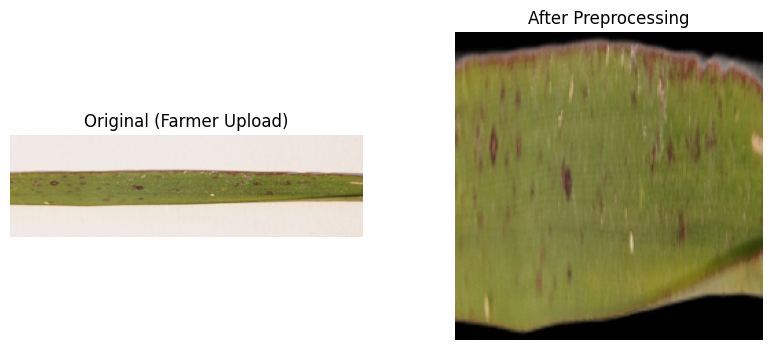


Predicted Disease : Leaf Smut
Confidence        : 67.5%

All Probabilities:
  bacterial_leaf_blight: 12.4%
  brown_spot: 20.0%
  leaf_smut: 67.5%


In [24]:
# Real World Images Testing
import matplotlib.pyplot as plt

def show_prediction(image_path):
    # Preprocess and show intermediate result
    processed = preprocess_farmer_image(image_path)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(Image.open(image_path))
    axes[0].set_title("Original (Farmer Upload)")
    axes[0].axis("off")

    axes[1].imshow(processed)
    axes[1].set_title("After Preprocessing")
    axes[1].axis("off")
    plt.show()

    # Predict
    result = predict_disease(image_path, model, CLASS_NAMES)
    print(f"\nPredicted Disease : {result['disease'].replace('_', ' ').title()}")
    print(f"Confidence        : {result['confidence']}")
    print(f"\nAll Probabilities:")
    for disease, prob in result['all_probs'].items():
        print(f"  {disease}: {prob}")

# Test it
show_prediction("/content/drive/MyDrive/rice_disease_dataset/leaf_smut/DSC_0319.jpg")

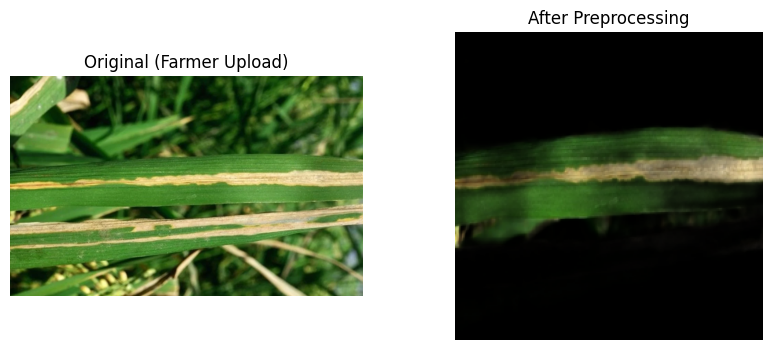


Predicted Disease : Bacterial Leaf Blight
Confidence        : 50.1%

All Probabilities:
  bacterial_leaf_blight: 50.1%
  brown_spot: 16.1%
  leaf_smut: 33.8%


In [27]:
# Real World Images Testing
import matplotlib.pyplot as plt

def show_prediction(image_path):
    # Preprocess and show intermediate result
    processed = preprocess_farmer_image(image_path)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(Image.open(image_path))
    axes[0].set_title("Original (Farmer Upload)")
    axes[0].axis("off")

    axes[1].imshow(processed)
    axes[1].set_title("After Preprocessing")
    axes[1].axis("off")
    plt.show()

    # Predict
    result = predict_disease(image_path, model, CLASS_NAMES)
    print(f"\nPredicted Disease : {result['disease'].replace('_', ' ').title()}")
    print(f"Confidence        : {result['confidence']}")
    print(f"\nAll Probabilities:")
    for disease, prob in result['all_probs'].items():
        print(f"  {disease}: {prob}")

# Test it
show_prediction("bacterial blight test2.jpg")